In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn import datasets

LoadError: ArgumentError: Package numpy not found in current path.
- Run `import Pkg; Pkg.add("numpy")` to install the numpy package.

In [ ]:
iris = datasets.load_iris()
X = iris.data
target = iris.target
Y = to_categorical(target).astype("uint8")

In [ ]:
idx = 0
print(X[idx])
print(target[idx])
print(Y[idx])
idx = 50
print(X[idx])
print(target[idx])
print(Y[idx])
idx = 100
print(X[idx])
print(target[idx])
print(Y[idx])

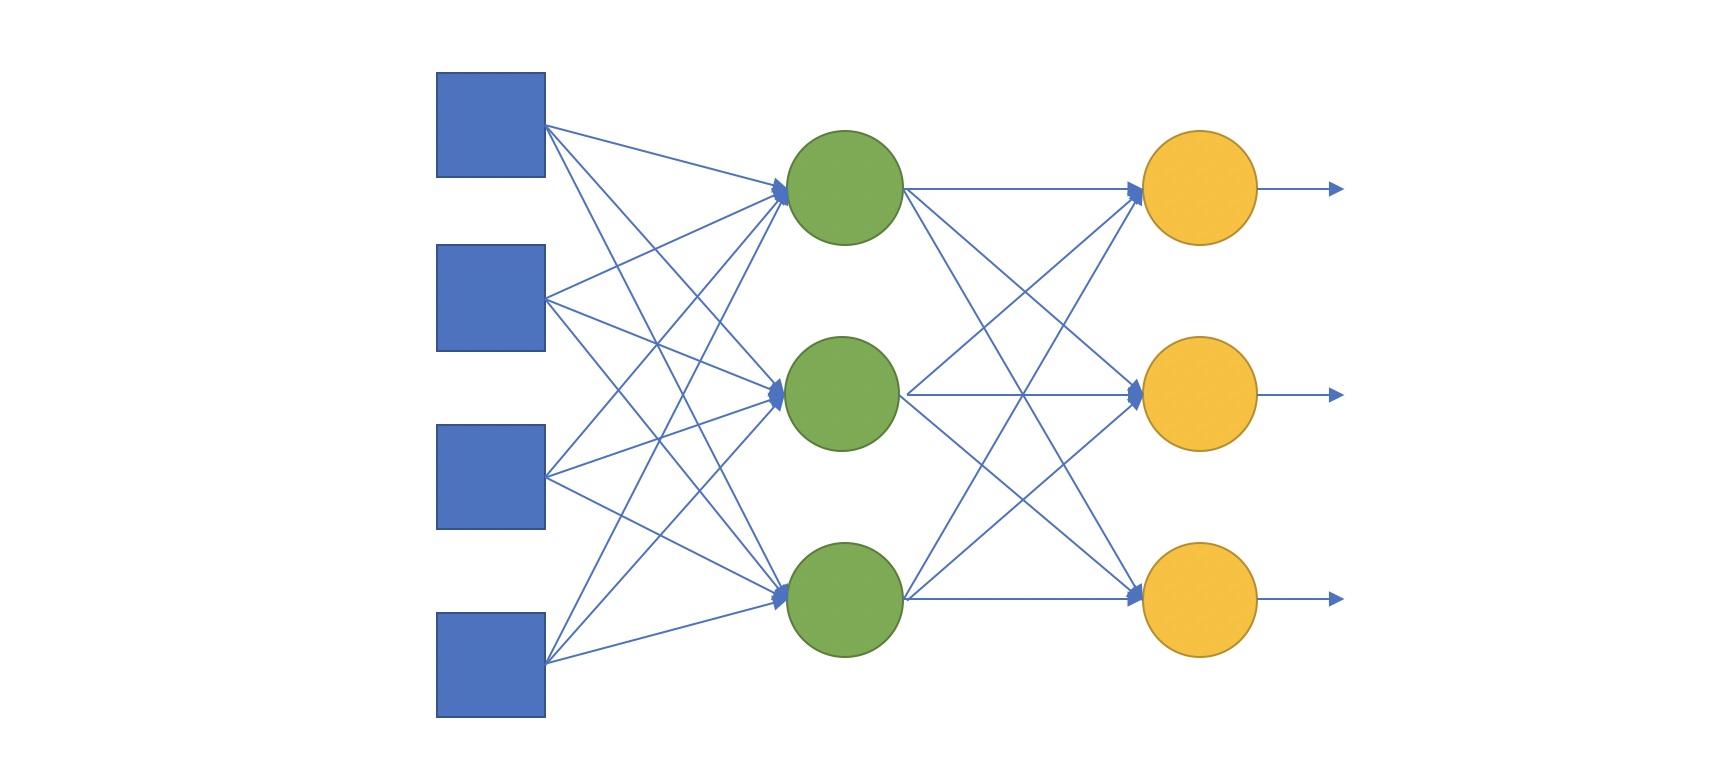

In [ ]:
# Topology: 4 x 3 x 3
input_size_layer1 = 4
num_neurons_layer1 = 3

input_size_layer2 = num_neurons_layer1
num_neurons_layer2 = 3

layer1 = list()
layer2 = list()

In [ ]:
def generate_weights(num_weights):
  w = np.zeros(num_weights)
  for i in range(len(w)):
    w[i] = np.random.rand(1) - 0.5
  return w

def init_weights():
  layer1.clear()
  layer2.clear()
  for i in range(num_neurons_layer1):
    layer1.append(generate_weights(input_size_layer1 + 1))
  for i in range(num_neurons_layer2):
    layer2.append(generate_weights(input_size_layer2 + 1))

def net_input(input_vector, w):
  net_input_var = w[0]
  for i in range(len(input_vector)):
    net_input_var += w[i + 1] * input_vector[i]
  return net_input_var

def sigmoid(z):
  return 1 / (1 + np.exp(-z))

def propagate(input_vector, w):
  neuron_input = net_input(input_vector, w)
  return sigmoid(neuron_input)

def calculate_error():
  total_error = 0
  for idx in range(len(X)):
    output_layer1 = np.zeros(num_neurons_layer1)
    for i in range(len(output_layer1)):
      output_layer1[i] = propagate(X[idx], layer1[i])

    output_layer2 = np.zeros(num_neurons_layer2)
    for i in range(len(output_layer2)):
      output_layer2[i] = propagate(output_layer1, layer2[i])

    total_error += np.square(Y[idx] - output_layer2).sum()

  return total_error / len(X)

In [ ]:
print(generate_weights(5))

In [ ]:
alpha = 0.03
epochs = 500

init_weights()

E = [calculate_error()]
for _ in range(epochs):
  for d in range(len(X)):
    output_layer1 = np.zeros(num_neurons_layer1)
    for i in range(len(output_layer1)):
      output_layer1[i] = propagate(X[d], layer1[i])

    output_layer2 = np.zeros(num_neurons_layer2)
    for i in range(len(output_layer2)):
      output_layer2[i] = propagate(output_layer1, layer2[i])

    delta_layer2 = np.zeros(num_neurons_layer2)
    for i in range(len(delta_layer2)):
      delta_layer2[i] = output_layer2[i] * (1 - output_layer2[i]) * (Y[d][i] - output_layer2[i])

    for i in range(len(layer2)):
      layer2[i][0] += alpha * delta_layer2[i]
      for j in range(len(layer2[i]) - 1):
        layer2[i][j + 1] += alpha * delta_layer2[i] * output_layer1[j]

    delta_layer1 = np.zeros(num_neurons_layer1)
    for i in range(len(delta_layer1)):
      weighted_delta_errors = 0
      for j in range(num_neurons_layer2):
        weighted_delta_errors += layer2[j][i + 1] * delta_layer2[j]
      delta_layer1[i] = output_layer1[i] * (1 - output_layer1[i]) * weighted_delta_errors

    for i in range(len(layer1)):
      layer1[i][0] += alpha * delta_layer1[i]
      for j in range(len(layer1[i]) - 1):
        layer1[i][j + 1] += alpha * delta_layer1[i] * X[d][j]

  E.append(calculate_error())

Error_vec = np.asarray(E)
plt.plot(Error_vec)
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.show()
print(f"Error inicial: {E[0]:.6f}")
print(f"Error final: {E[-1]:.6f}")

## Ejercicio 01: red profunda

La red original es `4 x 3 x 3`. Esta segunda corrida agrega exactamente dos capas ocultas y conserva sigmoide, MSE, `eta = 0.03` y `500` épocas: `4 x 3 x 3 x 3 x 3`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from tensorflow.keras.utils import to_categorical

iris_deep = datasets.load_iris()
X_deep = iris_deep.data.astype(float)
Y_deep = to_categorical(iris_deep.target).astype(float)
layer_sizes = [4, 3, 3, 3, 3]
learning_rate = 0.03
epochs_deep = 500

rng = np.random.default_rng(7)
weights_deep = [rng.uniform(-0.5, 0.5, (layer_sizes[i + 1], layer_sizes[i] + 1)) for i in range(len(layer_sizes) - 1)]

def sigmoid_deep(value):
    return 1 / (1 + np.exp(-np.clip(value, -500, 500)))

def forward_deep(input_vector):
    activations = [input_vector]
    for layer_weights in weights_deep:
        values_with_bias = np.insert(activations[-1], 0, 1.0)
        activations.append(sigmoid_deep(layer_weights @ values_with_bias))
    return activations

def error_deep():
    total = 0.0
    for sample, target in zip(X_deep, Y_deep):
        prediction = forward_deep(sample)[-1]
        total += np.square(target - prediction).sum()
    return total / len(X_deep)

errors_deep = [error_deep()]
for _ in range(epochs_deep):
    for sample, target in zip(X_deep, Y_deep):
        activations = forward_deep(sample)
        deltas = [None] * len(weights_deep)
        output = activations[-1]
        deltas[-1] = output * (1 - output) * (target - output)

        for layer_index in range(len(weights_deep) - 2, -1, -1):
            next_weights = weights_deep[layer_index + 1][:, 1:]
            current_output = activations[layer_index + 1]
            weighted_error = next_weights.T @ deltas[layer_index + 1]
            deltas[layer_index] = current_output * (1 - current_output) * weighted_error

        for layer_index, layer_weights in enumerate(weights_deep):
            input_with_bias = np.insert(activations[layer_index], 0, 1.0)
            layer_weights += learning_rate * np.outer(deltas[layer_index], input_with_bias)

    errors_deep.append(error_deep())

plt.plot(errors_deep, label="4 x 3 x 3 x 3 x 3")
plt.xlabel("Épocas")
plt.ylabel("Error MSE")
plt.title("MLP NumPy: red profunda")
plt.legend()
plt.show()
print(f"Error inicial: {errors_deep[0]:.6f}")
print(f"Error final: {errors_deep[-1]:.6f}")

LoadError: ArgumentError: Package numpy not found in current path.
- Run `import Pkg; Pkg.add("numpy")` to install the numpy package.

## Versión optimizada: error casi nulo

La red anterior usa sigmoides y MSE, lo que puede producir gradientes pequeños al apilar capas. En esta versión se estandarizan los cuatro atributos, se agregan tres capas ocultas de 16, 16 y 8 neuronas, se usa `ReLU` en las capas ocultas, `softmax` en la salida, entropía cruzada y Adam. Esta configuración es más adecuada para clasificación multiclase.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

X_optimized = (X - X.mean(axis=0)) / X.std(axis=0)
Y_optimized = Y.astype("float32")
tf.keras.utils.set_random_seed(7)

optimized_model = keras.Sequential(
    [
        layers.Input(shape=(4,)),
        layers.Dense(16, activation="relu", name="hidden1"),
        layers.Dense(16, activation="relu", name="hidden2"),
        layers.Dense(8, activation="relu", name="hidden3"),
        layers.Dense(3, activation="softmax", name="output"),
    ],
    name="optimized_mlp",
)

optimized_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

optimized_history = optimized_model.fit(
    X_optimized,
    Y_optimized,
    epochs=500,
    verbose=0,
)

plt.figure(figsize=(8, 5))
plt.plot(optimized_history.history["loss"])
plt.xlabel("Épocas")
plt.ylabel("Pérdida: entropía cruzada")
plt.title("Versión optimizada")
plt.show()

final_loss = optimized_history.history["loss"][-1]
final_accuracy = optimized_history.history["accuracy"][-1]
print(f"Pérdida final: {final_loss:.8f}")
print(f"Exactitud final: {final_accuracy:.2%}")
optimized_model.summary()